Quais são as características físicas e funcionais da rede que servirão de base para a geração de trajetórias?

### Characterization of the Road Network

This notebook characterizes the street network extracted from OpenStreetMap.

The objective is to enrich the network with additional attributes that will be used in routing, trajectory generation and entropy calculations.

#### Objetivo

| Coluna          | Descrição                      |
| --------------- | ------------------------------ |
| `road_type`     | Hierarquia simplificada da via |
| `length`        | Comprimento (m)                |
| `lanes`         | Número de faixas               |
| `maxspeed`      | Velocidade                     |
| `oneway`        | Sentido da via                 |
| `name`          | Nome da rua                    |
| `allowed_modes` | Modos permitidos               |
| `travel_time`   | Tempo estimado (opcional)      |

#### Result
| edge | name                    | road_type       | modal | length | betweenness |
| ---- | ----------------------- | --------------- | ----- | ------ | ----------- |
| 1    | Av. Osvaldo Aranha      | Via Arterial    | car   | 120    | 0.32        |
| 2    | Corredor Osvaldo Aranha | Corredor Ônibus | bus   | 120    | 0.45        |
| 3    | Rua X                   | Via Local       | car   | 80     | 0.02        |



In [18]:
import sys
from pathlib import Path

# adiciona a raiz do projeto ao Python
sys.path.append(str(Path.cwd().parent))

In [44]:
# BIBLIOTECAS

import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import json

import src.classification as classification
import src.visualization as visualization

import importlib

importlib.reload(classification)
importlib.reload(visualization)

<module 'src.visualization' from 'c:\\Users\\Simone\\Documents\\GitHub\\EtPilot\\src\\visualization.py'>

#### Carrega rede

In [26]:
graph = ox.load_graphml("../data/graph/rede-bomFim.graphml")

# Converte para geodataframes
gdf_nodes, gdf_edges = ox.graph_to_gdfs(graph)

In [27]:
print(
    "Nós:",
    len(graph.nodes),
    "\nArestas:",
    len(graph.edges)
)

Nós: 55 
Arestas: 90


#### Caracterizacao da rede

In [28]:
with open("../config/road_classification.json", "r", encoding="utf-8") as f:
    road_classification = json.load(f)
    
mapping = road_classification["en"]

In [30]:
gdf_edges["road_type"] = gdf_edges.apply(
    lambda x: classification.classify_road_type(
        x,
        mapping
    ),
    axis=1
)

gdf_edges["road_type"].value_counts()

road_type
Local Collector       29
Arterial Road         17
Collector Road        15
Bus Corridor          14
Residential Street    13
Other                  2
Name: count, dtype: int64

#### Caracterizacao modal

In [32]:
gdf_edges["modal"] = gdf_edges.apply(
    classification.classify_modal,
    axis=1
)

gdf_edges["modal"].value_counts()

modal
car      74
bus      14
other     2
Name: count, dtype: int64

In [33]:
# Comprimento das vias

# direto do OSMnx
# gdf_edges["length"]

# criando variavel
gdf_edges["length_km"] = (
    gdf_edges["length"] / 1000
)

gdf_edges.groupby(
    "road_type"
)["length_km"].sum()

road_type
Arterial Road         1.494021
Bus Corridor          2.686867
Collector Road        1.109495
Local Collector       3.753469
Other                 0.159622
Residential Street    1.322451
Name: length_km, dtype: float64

#### Densidade da rede

In [34]:
# Comprimento total da rede
total_length = gdf_edges.length.sum()

total_length / 1000

C:\Users\Simone\AppData\Local\Temp\ipykernel_55820\2300696370.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  total_length = gdf_edges.length.sum()


np.float64(0.00010227033809975747)

In [35]:
# Nmr de interseções
intersection_count = len(gdf_nodes)

intersection_count

55

In [36]:
# Densidade de nos
area = gdf_edges.to_crs(
    "EPSG:31983"
).total_bounds

#### Metricas de rede

In [37]:
# Grau medio
degree = dict(graph.degree())

mean_degree = sum(degree.values()) / len(degree)

mean_degree

3.272727272727273

Quanto maior:

mais conexões;
maior possibilidade de escolha de caminhos.

In [38]:
# Betweenness centrality
betweenness = nx.betweenness_centrality(
    graph,
    weight="length"
)

# Adiciona a medida de centralidade ao grafo
nx.set_node_attributes(
    graph,
    betweenness,
    "betweenness"
)

#### Identifica vias estruturantes

In [39]:
gdf_edges[
    gdf_edges["road_type"]=="Via Arterial"
].sort_values(
    "length",
    ascending=False
).head()

,,,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,bridge,road_type,modal,length_km
u,v,key,,,,,,,,,,,,,


#### Visualizações

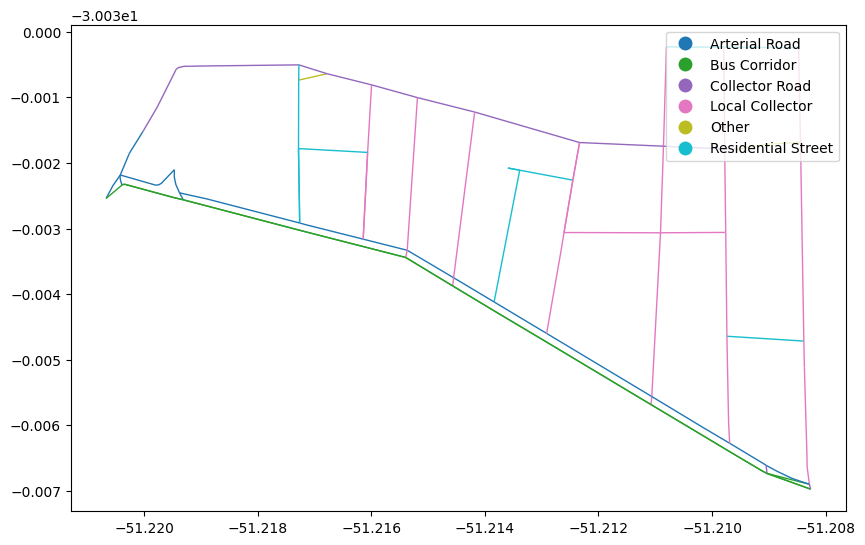

In [42]:
# Hierarquia viaria
fig, ax = plt.subplots(figsize=(10,10))

gdf_edges.plot(
    ax=ax,
    column="road_type",
    categorical=True,
    legend=True,
    linewidth=1
)

plt.show()

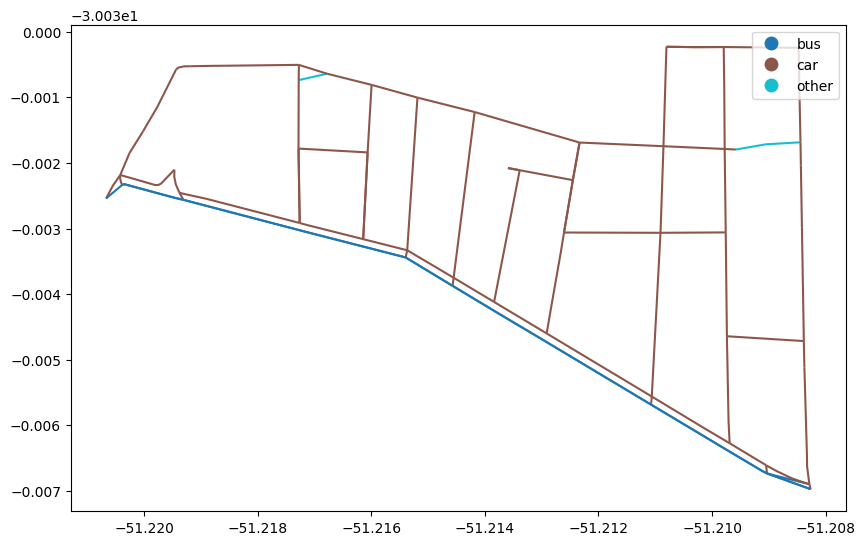

In [46]:
# Modal
fig, ax = plt.subplots(figsize=(10,10))

gdf_edges.plot(
    ax=ax,
    column="modal",
    categorical=True,
    legend=True
)

plt.show()

#### Exportações

In [47]:
gdf_edges.to_file(
    "../data/network_characterized.gpkg",
    layer="edges"
)

gdf_nodes.to_file(
    "../data/network_characterized.gpkg",
    layer="nodes"
)